# VA-π Mini — Giai đoạn 2: Kiểm tra kết quả "Implement: Mini"

Notebook này load checkpoint `vqvae_mini.pt` + `gpt_mini.pt` đã train xong (VQVAE 15 epoch, GPT 10 epoch, full CIFAR-10), rồi kiểm tra:
1. **Reconstruction error** của VQVAE (đo riêng chất lượng tokenizer, tách biệt khỏi lỗi GPT)
2. **Sample ảnh free-running** từ GPT theo từng class (kiểm tra sanity bằng mắt)
3. **FID / IS xấp xỉ** so với CIFAR-10 test set (không phải FID chuẩn 50k-sample như paper gốc — chỉ là proxy nhanh cho Mini)
4. Token usage của codebook (kiểm tra codebook collapse)

**Trước khi chạy:** sửa `CKPT_DIR` ở Cell 2 thành đúng path Kaggle Dataset bạn đã lưu checkpoint (`/kaggle/input/<tên-dataset-của-bạn>/checkpoints`).

## 1. Cài đặt & import

In [1]:
!pip install torch torchvision scipy matplotlib --quiet

In [2]:
import os
import sys
import shutil
import glob

# === TỰ ĐỘNG TÌM KIẾM ĐƯỜNG DẪN CODE VÀ CHECKPOINT TRÊN KAGGLE ===
vapi_mini_paths = glob.glob('/kaggle/input/**/vapi_mini', recursive=True)
CODE_DATASET_DIR = os.path.dirname(vapi_mini_paths[0]) if vapi_mini_paths else "/kaggle/input/datasets/caosfourn/vapi-mini-source"

ckpt_candidates = glob.glob('/kaggle/**/vqvae_mini.pt', recursive=True)
if ckpt_candidates:
    parent_dir = os.path.dirname(ckpt_candidates[0])
    CKPT_DATASET_DIR = os.path.dirname(parent_dir) if os.path.basename(parent_dir) == "checkpoints" else parent_dir
else:
    CKPT_DATASET_DIR = "/kaggle/input/notebooks/caosfourn/train_mini"

WORK_DIR = "/kaggle/working/vapi_mini"

# Copy code sang working để import được bình thường
if not os.path.exists(WORK_DIR):
    zip_candidates = [f for f in os.listdir(CODE_DATASET_DIR) if f.endswith(".zip")] if os.path.exists(CODE_DATASET_DIR) else []
    if zip_candidates:
        import zipfile
        with zipfile.ZipFile(os.path.join(CODE_DATASET_DIR, zip_candidates[0])) as z:
            z.extractall("/kaggle/working/")
    else:
        shutil.copytree(os.path.join(CODE_DATASET_DIR, "vapi_mini"), WORK_DIR)

sys.path.append(WORK_DIR)
os.chdir(WORK_DIR)
print("Working dir:", os.getcwd())
print("Nội dung:", os.listdir(WORK_DIR))

Working dir: /kaggle/working/vapi_mini
Nội dung: ['README.md', 'models', '.git', '.gitignore', 'checkpoints_pretrained', 'notebooks', 'report.md', 'data', 'scripts']


In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np

from scripts.eval_utils import (
    load_checkpoints,
    sample_and_decode,
    compute_reconstruction_error,
    denormalize,
    get_inception_features,
    compute_fid,
    compute_inception_score,
)
from data.data_utils import get_cifar10_loaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 2. Load checkpoint

In [4]:
VQVAE_PATH = os.path.join(CKPT_DATASET_DIR, "checkpoints", "vqvae_mini.pt")
GPT_PATH = os.path.join(CKPT_DATASET_DIR, "checkpoints", "gpt_mini.pt")

# nếu cấu trúc dataset của bạn khác (không có thư mục con "checkpoints"),
# sửa 2 dòng trên cho khớp. Có thể kiểm tra nhanh bằng:
print(os.listdir(CKPT_DATASET_DIR))

vqvae, gpt, seq_len = load_checkpoints(VQVAE_PATH, GPT_PATH, device)
print(f"seq_len (số token/ảnh): {seq_len}")

['checkpoints', '__results__.html', 'vapi_mini', '__notebook__.ipynb', '__output__.json', 'data', 'custom.css']
Đã load VQVAE: codebook=256, downsample=4
Đã load GPT: dim=256, depth=6, seq_len=64, num_classes=10
seq_len (số token/ảnh): 64


## 3. Load dữ liệu test (CIFAR-10) để so sánh

In [5]:
train_loader, test_loader, num_classes = get_cifar10_loaders(
    root="/kaggle/working/data", image_size=32, batch_size=128
)
CIFAR10_CLASSES = ["airplane","automobile","bird","cat","deer",
                    "dog","frog","horse","ship","truck"]
print(f"Test set: {len(test_loader.dataset)} ảnh, {num_classes} class")

100%|██████████| 170M/170M [29:13<00:00, 97.2kB/s]


Test set: 10000 ảnh, 10 class


## 4. Reconstruction error của VQVAE
Đo MSE giữa ảnh gốc và ảnh reconstruct **bằng đúng token đã encode** (không qua GPT). Số này cho biết "sàn" chất lượng — GPT không thể tạo ảnh tốt hơn khả năng decode của VQVAE.

In [6]:
recon_mse = compute_reconstruction_error(vqvae, test_loader, device, max_batches=20)
print(f"VQVAE reconstruction MSE (test set, ảnh trong [-1,1]): {recon_mse:.4f}")
print("Tham khảo: MSE < 0.05 là khá tốt cho VQVAE nhỏ trên CIFAR-10 32x32;")
print("MSE > 0.3 cho thấy tokenizer học chưa tốt (cần train thêm epoch hoặc tăng codebook).")

VQVAE reconstruction MSE (test set, ảnh trong [-1,1]): 0.0223
Tham khảo: MSE < 0.05 là khá tốt cho VQVAE nhỏ trên CIFAR-10 32x32;
MSE > 0.3 cho thấy tokenizer học chưa tốt (cần train thêm epoch hoặc tăng codebook).


## 5. Trực quan: ảnh gốc vs ảnh reconstruct vs ảnh sample mới
- **Dòng 1**: ảnh gốc CIFAR-10
- **Dòng 2**: ảnh reconstruct qua VQVAE (encode-decode, không qua GPT) — kiểm tra tokenizer
- **Dòng 3**: ảnh sinh mới hoàn toàn (free-running qua GPT rồi decode) — kiểm tra generative quality thật

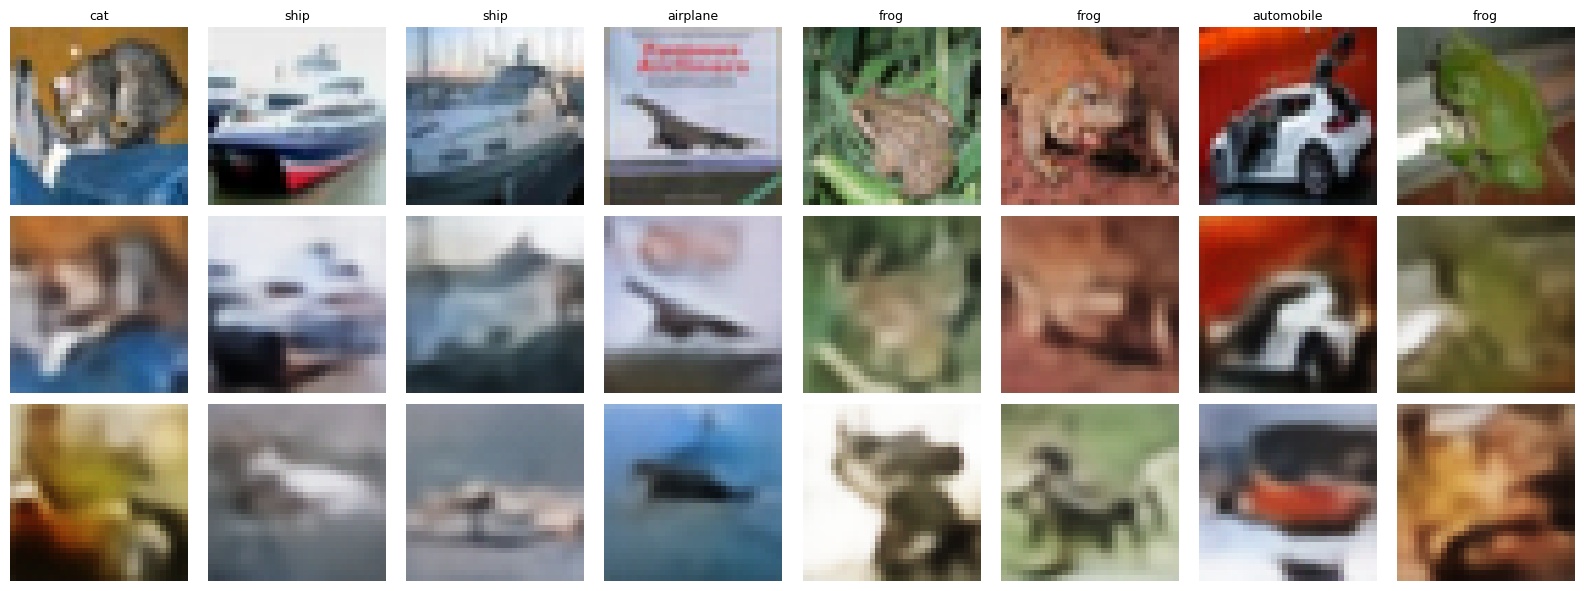

Đã lưu hình: /kaggle/working/sanity_check_grid.png


In [7]:
n_show = 8
sample_images, sample_labels = next(iter(test_loader))
sample_images = sample_images[:n_show].to(device)
sample_labels = sample_labels[:n_show]

with torch.no_grad():
    indices, _, _ = vqvae.encode(sample_images)
    recon = vqvae.decode_from_indices(indices)

generated = sample_and_decode(vqvae, gpt, sample_labels, device, temperature=1.0, top_k=50)

fig, axes = plt.subplots(3, n_show, figsize=(2*n_show, 6))
orig_disp = denormalize(sample_images).cpu()
recon_disp = denormalize(recon).cpu()
gen_disp = generated.cpu()

for i in range(n_show):
    axes[0, i].imshow(orig_disp[i].permute(1, 2, 0).numpy())
    axes[0, i].set_title(CIFAR10_CLASSES[sample_labels[i]], fontsize=9)
    axes[0, i].axis("off")
    axes[1, i].imshow(recon_disp[i].permute(1, 2, 0).numpy())
    axes[1, i].axis("off")
    axes[2, i].imshow(gen_disp[i].permute(1, 2, 0).numpy())
    axes[2, i].axis("off")

axes[0, 0].set_ylabel("Gốc", fontsize=11)
axes[1, 0].set_ylabel("Reconstruct\n(VQVAE only)", fontsize=11)
axes[2, 0].set_ylabel("Generated\n(free-running)", fontsize=11)
plt.tight_layout()
plt.savefig("/kaggle/working/sanity_check_grid.png", dpi=120)
plt.show()
print("Đã lưu hình: /kaggle/working/sanity_check_grid.png")

**Cách đọc kết quả ở bước này:**
- Nếu dòng 2 (reconstruct) đã mờ/nhiễu nhiều → lỗi nằm ở VQVAE, cần train VQVAE thêm hoặc tăng codebook/latent_dim.
- Nếu dòng 2 khá tốt nhưng dòng 3 (generated) tệ hơn rõ rệt → lỗi nằm ở GPT (NTP loss chưa hội tụ tốt, hoặc cần train thêm epoch / tăng model size).
- Với model Mini (vài triệu param, 10 epoch), ảnh sinh ra **mờ và không sắc nét bằng paper gốc là HOÀN TOÀN BÌNH THƯỜNG** — mục tiêu của Giai đoạn 2 chỉ là chứng minh pipeline đúng và loss giảm có ý nghĩa, không phải đạt SOTA.

## 6. Token usage của codebook (kiểm tra codebook collapse)
Nếu chỉ một phần nhỏ codebook được dùng (vd <10%), nghĩa là VQVAE chưa học đa dạng — cần lưu ý khi viết báo cáo.

Codebook usage: 37/256 (14.5%) các mã được dùng


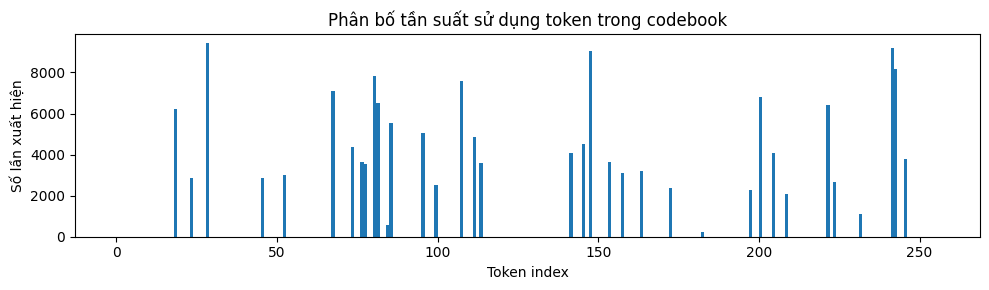

In [8]:
all_indices = []
with torch.no_grad():
    for i, (imgs, _) in enumerate(test_loader):
        if i >= 20:
            break
        idx, _, _ = vqvae.encode(imgs.to(device))
        all_indices.append(idx.reshape(-1).cpu())
all_indices = torch.cat(all_indices)
codebook_size = vqvae.codebook_size
used = all_indices.unique().numel()
print(f"Codebook usage: {used}/{codebook_size} ({100*used/codebook_size:.1f}%) các mã được dùng")

plt.figure(figsize=(10, 3))
plt.hist(all_indices.numpy(), bins=codebook_size, range=(0, codebook_size))
plt.title("Phân bố tần suất sử dụng token trong codebook")
plt.xlabel("Token index")
plt.ylabel("Số lần xuất hiện")
plt.tight_layout()
plt.savefig("/kaggle/working/codebook_usage.png", dpi=120)
plt.show()

## 7. FID / IS xấp xỉ trên CIFAR-10 test set
**Lưu ý quan trọng (ghi vào báo cáo):** đây là FID/IS xấp xỉ dùng vài nghìn ảnh test thay vì 50k ảnh như paper gốc, và dùng InceptionV3 pretrained ImageNet thông thường (không phải pipeline FID chuẩn của OpenAI dùng cho LlamaGen). Số liệu này chỉ dùng để **so sánh tương đối trước/sau VA-π fine-tuning ở Giai đoạn 3**, không nên so sánh trực tiếp với số liệu FID trong paper gốc.

In [9]:
N_EVAL = 1000  # số ảnh dùng để tính FID/IS xấp xỉ (tăng lên nếu có thời gian/GPU)

# --- lấy N_EVAL ảnh thật từ test set ---
real_images = []
real_labels = []
for imgs, labels in test_loader:
    real_images.append(imgs)
    real_labels.append(labels)
    if sum(x.shape[0] for x in real_images) >= N_EVAL:
        break
real_images = torch.cat(real_images)[:N_EVAL]
real_labels = torch.cat(real_labels)[:N_EVAL]
real_images_01 = denormalize(real_images)

# --- sinh N_EVAL ảnh giả bằng GPT (free-running), dùng class label thật để so sánh công bằng ---
fake_images_01 = []
batch_size_gen = 64
for i in range(0, N_EVAL, batch_size_gen):
    labels_batch = real_labels[i:i+batch_size_gen]
    imgs = sample_and_decode(vqvae, gpt, labels_batch, device, temperature=1.0, top_k=50)
    fake_images_01.append(imgs.cpu())
fake_images_01 = torch.cat(fake_images_01)[:N_EVAL]

print(f"Đã chuẩn bị {real_images_01.shape[0]} ảnh thật và {fake_images_01.shape[0]} ảnh sinh ra.")

Đã chuẩn bị 1000 ảnh thật và 1000 ảnh sinh ra.


In [10]:
print("Đang trích xuất feature Inception cho ảnh thật...")
real_feats = get_inception_features(real_images_01, device)
print("Đang trích xuất feature Inception cho ảnh sinh ra...")
fake_feats = get_inception_features(fake_images_01, device)

fid_score = compute_fid(real_feats, fake_feats)
print(f"\nFID xấp xỉ (CIFAR-10 test, N={N_EVAL}): {fid_score:.2f}")
print("(FID thấp hơn = ảnh sinh ra gần phân phối ảnh thật hơn)")

Đang trích xuất feature Inception cho ảnh thật...
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 174MB/s] 


Đang trích xuất feature Inception cho ảnh sinh ra...

FID xấp xỉ (CIFAR-10 test, N=1000): 107.73
(FID thấp hơn = ảnh sinh ra gần phân phối ảnh thật hơn)


In [11]:
is_mean, is_std = compute_inception_score(fake_images_01, device)
print(f"Inception Score xấp xỉ: {is_mean:.2f} ± {is_std:.2f}")
print("(IS cao hơn = ảnh đa dạng và rõ ràng theo class hơn)")

print("\n=== TÓM TẮT GIAI ĐOẠN 2 (Implement: Mini) ===")
print(f"VQVAE reconstruction MSE : {recon_mse:.4f}")
print(f"Codebook usage           : {used}/{codebook_size} ({100*used/codebook_size:.1f}%)")
print(f"FID xấp xỉ (free-running): {fid_score:.2f}")
print(f"IS xấp xỉ (free-running) : {is_mean:.2f} ± {is_std:.2f}")
print("\n=> Lưu các số này lại, sẽ dùng làm BASELINE để so sánh sau khi áp VA-π ở Giai đoạn 3.")

Inception Score xấp xỉ: 2.91 ± 0.09
(IS cao hơn = ảnh đa dạng và rõ ràng theo class hơn)

=== TÓM TẮT GIAI ĐOẠN 2 (Implement: Mini) ===
VQVAE reconstruction MSE : 0.0223
Codebook usage           : 37/256 (14.5%)
FID xấp xỉ (free-running): 107.73
IS xấp xỉ (free-running) : 2.91 ± 0.09

=> Lưu các số này lại, sẽ dùng làm BASELINE để so sánh sau khi áp VA-π ở Giai đoạn 3.


## 8. Lưu số liệu baseline để dùng cho Giai đoạn 3

In [12]:
import json

baseline_metrics = {
    "vqvae_reconstruction_mse": recon_mse,
    "codebook_usage_pct": 100 * used / codebook_size,
    "fid_approx": fid_score,
    "is_approx_mean": is_mean,
    "is_approx_std": is_std,
    "n_eval_images": N_EVAL,
    "note": "FID/IS xấp xỉ, không phải chuẩn 50k-sample như paper gốc. Dùng để so sánh tương đối trước/sau VA-π."
}

with open("/kaggle/working/baseline_metrics_mini.json", "w") as f:
    json.dump(baseline_metrics, f, indent=2, ensure_ascii=False)

print("Đã lưu: /kaggle/working/baseline_metrics_mini.json")
print(json.dumps(baseline_metrics, indent=2, ensure_ascii=False))

Đã lưu: /kaggle/working/baseline_metrics_mini.json
{
  "vqvae_reconstruction_mse": 0.022320597370465597,
  "codebook_usage_pct": 14.453125,
  "fid_approx": 107.7264373001651,
  "is_approx_mean": 2.913494825363159,
  "is_approx_std": 0.08988067507743835,
  "n_eval_images": 1000,
  "note": "FID/IS xấp xỉ, không phải chuẩn 50k-sample như paper gốc. Dùng để so sánh tương đối trước/sau VA-π."
}


## 9. Đánh giá Benchmark Hoàn chỉnh (FID / IS / Precision / Recall)

Phần này tính **đầy đủ 4 chỉ số** theo Bảng 2 trong paper VA-π gốc:

| Chỉ số | Ý nghĩa |
|---|---|
| **FID ↓** | Khoảng cách Fréchet giữa phân phối ảnh thật và ảnh sinh |
| **IS ↑** | Inception Score — đo chất lượng và đa dạng |
| **Precision ↑** | Tỷ lệ ảnh sinh nằm trong manifold ảnh thật (fidelity) |
| **Recall ↑** | Tỷ lệ ảnh thật nằm trong manifold ảnh sinh (diversity) |

> **Lưu ý:** Đây là xấp xỉ trên `N_EVAL` mẫu — dùng làm **baseline** so sánh với model sau RL fine-tuning.

In [13]:
import sys, os, json, torch

sys.path.insert(0, os.path.abspath('scripts'))
from eval_utils import compute_all_metrics, denormalize

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Lấy ảnh thật (denormalize [-1,1] -> [0,1]) ---
real_list = []
for imgs, _ in test_loader:
    real_list.append(imgs)
    if sum(x.shape[0] for x in real_list) >= N_EVAL:
        break
real_images = denormalize(torch.cat(real_list, dim=0)[:N_EVAL]).to(device)  # [0,1]

# --- Sinh ảnh giả (cũng [0,1] qua denormalize) ---
gpt.eval(); vqvae.eval()
fake_list = []
n_generated = 0
batch_size_gen = 32
with torch.no_grad():
    while n_generated < N_EVAL:
        n_batch = min(batch_size_gen, N_EVAL - n_generated)
        labels = torch.randint(0, num_classes, (n_batch,), device=device)
        token_ids = gpt.generate(class_ids=labels, temperature=1.0)
        side = int(seq_len ** 0.5)
        token_ids_2d = token_ids.reshape(n_batch, side, side)
        imgs_gen = denormalize(vqvae.decode_from_indices(token_ids_2d))  # [0,1]
        fake_list.append(imgs_gen)
        n_generated += n_batch
fake_images = torch.cat(fake_list, dim=0)[:N_EVAL]

# --- Tính 4 chỉ số (cả 2 đầu vào đều [0,1]) ---
print(f'Tính benchmark trên {N_EVAL} mẫu...\n')
metrics_baseline = compute_all_metrics(
    real_images=real_images, fake_images=fake_images, device=device,
    inception_batch_size=64, is_splits=5, knn_k=3,
)

# --- Lưu kết quả ---
baseline_full = {
    'model': 'VA-π Mini (Baseline — trước RL)',
    'dataset': 'CIFAR-10',
    'vqvae_reconstruction_mse': float(recon_mse),
    'codebook_usage_pct': float(100 * used / codebook_size),
    **metrics_baseline,
    'n_eval_images': N_EVAL,
    'note': 'Xấp xỉ trên N_EVAL mẫu (không phải chuẩn 50k của paper gốc)',
}
with open('/kaggle/working/baseline_metrics_full.json', 'w') as f:
    json.dump(baseline_full, f, indent=2, ensure_ascii=False)

print('\nĐã lưu: /kaggle/working/baseline_metrics_full.json')
print(json.dumps(baseline_full, indent=2, ensure_ascii=False))


Tính benchmark trên 1000 mẫu...

[compute_all_metrics] Trích xuất Inception features cho ảnh thật...
[compute_all_metrics] Trích xuất Inception features cho ảnh sinh...
[compute_all_metrics] Tính FID...
[compute_all_metrics] Tính Inception Score (IS)...
[compute_all_metrics] Tính Precision & Recall (k=3)...

Metric                    Value
----------------------------------------------------
FID ↓                  109.7014
IS ↑ (mean)              2.8567
IS ↑ (std)               0.0515
Precision ↑              0.7890
Recall ↑                 0.0480

Đã lưu: /kaggle/working/baseline_metrics_full.json
{
  "model": "VA-π Mini (Baseline — trước RL)",
  "dataset": "CIFAR-10",
  "vqvae_reconstruction_mse": 0.022320597370465597,
  "codebook_usage_pct": 14.453125,
  "fid": 109.7014,
  "is_mean": 2.8567,
  "is_std": 0.0515,
  "precision": 0.789,
  "recall": 0.048,
  "n_eval_images": 1000,
  "note": "Xấp xỉ trên N_EVAL mẫu (không phải chuẩn 50k của paper gốc)"
}
